In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from decimal import ROUND_HALF_UP, Decimal

In [10]:
df  = pd.read_csv('input\jpx-tokyo-stock-exchange-prediction\\training_price_features.csv')
df ['Date'] = pd.to_datetime(df ['Date'])


df.tail()


,RowId,Date,SecuritiesCode,Open,High,Low,Close,Volume,AdjustmentFactor,ExpectedDividend,...,ExpMovingAvg_20Day,Volatility_20Day,Return_30Day,MovingAvg_30Day,ExpMovingAvg_30Day,Volatility_30Day,Return_50Day,MovingAvg_50Day,ExpMovingAvg_50Day,Volatility_50Day
1880526,20201224_9997,2020-12-24,9997,995.0,1037.0,995.0,1025.0,332300,1.0,0,...,964.393846,0.027769,0.163451,942.633333,954.598641,0.026044,0.067708,937.98,943.106150,0.034980
1880527,20201225_9997,2020-12-25,9997,1018.0,1072.0,1018.0,1065.0,426200,1.0,0,...,973.975385,0.028869,0.241259,949.533333,961.721310,0.026026,0.134185,940.50,947.886301,0.035197
1880528,20201228_9997,2020-12-28,9997,1080.0,1096.0,1050.0,1072.0,391400,1.0,0,...,983.311062,0.028549,0.227950,956.166667,968.836064,0.025956,0.169029,943.60,952.753504,0.034996
1880529,20201229_9997,2020-12-29,9997,1070.0,1095.0,1061.0,1092.0,199000,1.0,0,...,993.662390,0.028623,0.221477,962.766667,976.782124,0.025855,0.176724,946.88,958.214151,0.035042
1880530,20201230_9997,2020-12-30,9997,1092.0,1140.0,1076.0,1134.0,338900,1.0,0,...,1007.027876,0.028294,0.240700,970.100000,986.925213,0.026329,0.193684,950.56,965.107714,0.035268


### Add return_1day

In [11]:
df['return_1day'] = df['AdjustedClose'].pct_change(1)
df.head(5)

C:\Users\mhwu9\AppData\Local\Temp\ipykernel_14808\4234748944.py:1: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['return_1day'] = df['AdjustedClose'].pct_change(1)


,RowId,Date,SecuritiesCode,Open,High,Low,Close,Volume,AdjustmentFactor,ExpectedDividend,...,Volatility_20Day,Return_30Day,MovingAvg_30Day,ExpMovingAvg_30Day,Volatility_30Day,Return_50Day,MovingAvg_50Day,ExpMovingAvg_50Day,Volatility_50Day,return_1day
0,20170104_1301,2017-01-04,1301,2734.0,2755.0,2730.0,2742.0,31400,1.0,0,...,NaN,NaN,NaN,2742.000000,NaN,NaN,NaN,2742.000000,NaN,NaN
1,20170105_1301,2017-01-05,1301,2743.0,2747.0,2735.0,2738.0,17900,1.0,0,...,NaN,NaN,NaN,2741.741935,NaN,NaN,NaN,2741.843137,NaN,-0.001459
2,20170106_1301,2017-01-06,1301,2734.0,2744.0,2720.0,2740.0,19900,1.0,0,...,NaN,NaN,NaN,2741.629553,NaN,NaN,NaN,2741.770857,NaN,0.000730
3,20170110_1301,2017-01-10,1301,2745.0,2754.0,2735.0,2748.0,24200,1.0,0,...,NaN,NaN,NaN,2742.040549,NaN,NaN,NaN,2742.015137,NaN,0.002920
4,20170111_1301,2017-01-11,1301,2748.0,2752.0,2737.0,2745.0,9300,1.0,0,...,NaN,NaN,NaN,2742.231481,NaN,NaN,NaN,2742.132191,NaN,-0.001092


### Analyze Correlation

Correlation with Target:
SecuritiesCode               -0.004791
Open                         -0.002812
High                         -0.002753
Low                          -0.002926
Close                        -0.002864
Volume                       -0.002170
AdjustmentFactor             -0.000085
ExpectedDividend             -0.035902
CumulativeAdjustmentFactor   -0.000044
AdjustedClose                -0.005288
Return_5Day                  -0.001807
MovingAvg_5Day               -0.005188
ExpMovingAvg_5Day            -0.005219
Volatility_5Day               0.010817
Return_10Day                 -0.008673
MovingAvg_10Day              -0.005038
ExpMovingAvg_10Day           -0.005165
Volatility_10Day              0.018041
Return_20Day                 -0.000094
MovingAvg_20Day              -0.005009
ExpMovingAvg_20Day           -0.005100
Volatility_20Day              0.021988
Return_30Day                 -0.000636
MovingAvg_30Day              -0.004681
ExpMovingAvg_30Day           -0.005020


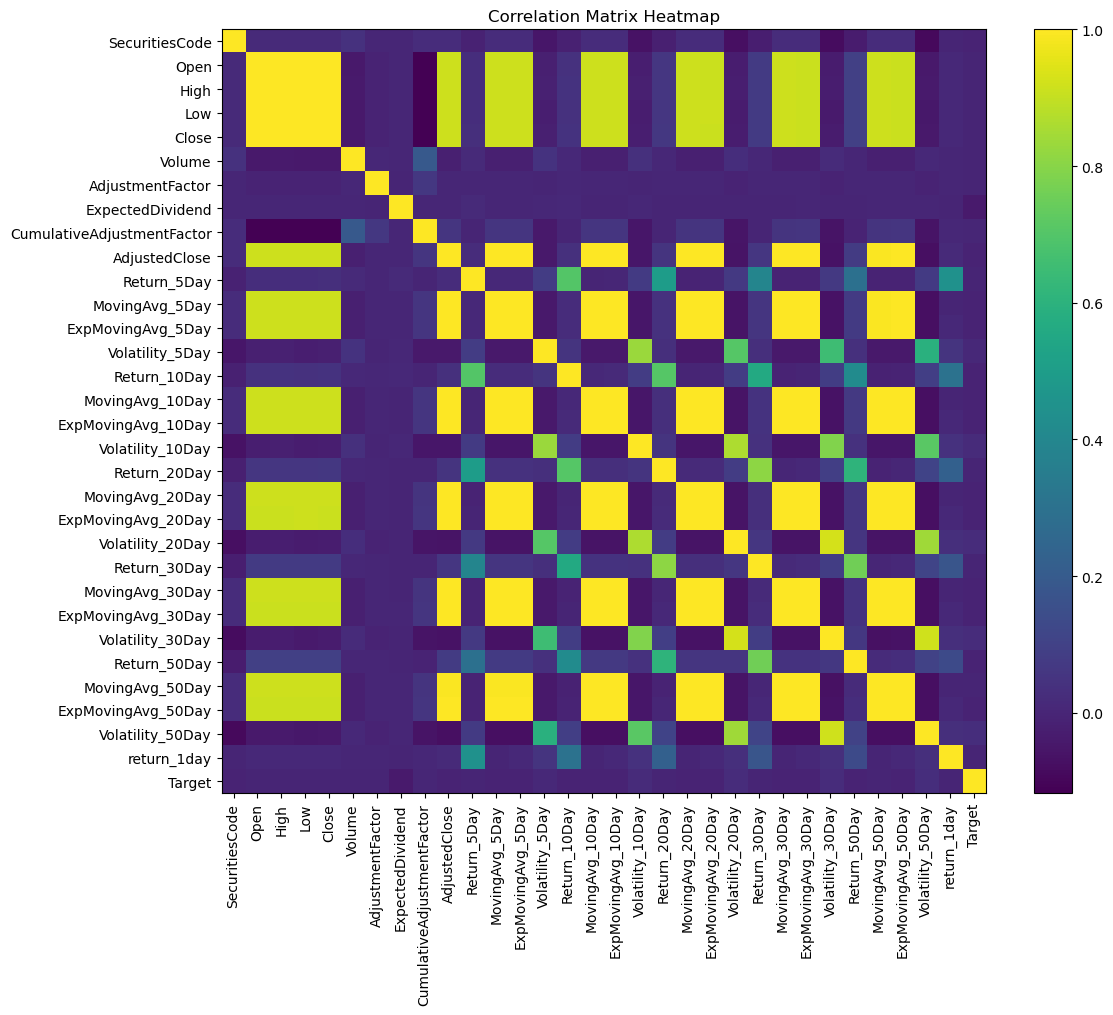

In [12]:
df_numeric = df.select_dtypes(include=['float64', 'int64'])

# Reorder the columns so that "Target" is at the very right (last column)
if "Target" in df_numeric.columns:
    cols = [col for col in df_numeric.columns if col != "Target"] + ["Target"]
    df_numeric = df_numeric[cols]
else:
    print("Warning: 'Target' column not found in numeric columns.")

# Calculate the correlation matrix for all numeric features
corr_matrix = df_numeric.corr()

# Print the correlation between each feature and the Target column
print("Correlation with Target:")
print(corr_matrix['Target'])

# ----------------------------------------
# 1. Visualize the full correlation matrix as a heatmap
# ----------------------------------------
plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, cmap='viridis', interpolation='none')
plt.colorbar()
plt.xticks(ticks=np.arange(len(corr_matrix.columns)), labels=corr_matrix.columns, rotation=90)
plt.yticks(ticks=np.arange(len(corr_matrix.index)), labels=corr_matrix.index)
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()
